**Logistic Regression — From Scratch**

Despite the name — it is a classification algorithm not regression.
It predicts the probability that something belongs to a class.\
Output of Linear Regression — any number (-∞ to +∞)\
Output of Logistic Regression — probability (0 to 1)

**Real example**:\
Patient has these symptoms — probability of disease = 0.87\
If probability > 0.5 → Disease (class 1)\
If probability < 0.5 → No Disease (class 0)\

**How it Works**\
Linear Regression gives any number. Logistic Regression passes that number through a Sigmoid function that converts it to 0-1.\
Sigmoid(x) = 1 / (1 + e^(-x))\
Any large positive number → close to 1\
Any large negative number → close to 0\
0 → exactly 0.5

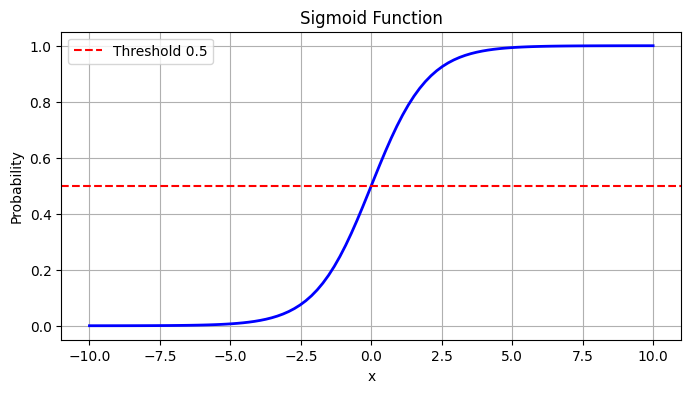

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid, color="blue", linewidth=2)
plt.axhline(y=0.5, color="red", linestyle="--", label="Threshold 0.5")
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()


This S-shaped curve converts any number to probability between 0 and 1.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

# Dataset
# Heart disease style dataset
np.random.seed(42)
n = 200

data = {
    "age":             np.random.randint(30, 70, n),
    "cholesterol":     np.random.randint(150, 300, n),
    "blood_pressure":  np.random.randint(80, 160, n),
    "max_heart_rate":  np.random.randint(100, 200, n),
    "disease":         np.random.randint(0, 2, n)   # 0=no disease, 1=disease
}

df = pd.DataFrame(data)
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nDisease distribution:\n{df['disease'].value_counts()}")

   age  cholesterol  blood_pressure  max_heart_rate  disease
0   68          273             157             149        1
1   58          219             148             127        1
2   44          242             126             191        1
3   37          152             141             140        1
4   50          297             148             199        0

Shape: (200, 5)

Disease distribution:
disease
1    102
0     98
Name: count, dtype: int64


**Why StandardScaler here?**

Logistic Regression is distance based internally. Features with large values dominate.

Without scaling
- age    : 25, 30, 45       — small numbers
- salary : 30000, 50000     — large numbers

Salary dominates — age ignored

With scaling — both same range

- age    : -1.2, 0.0, 1.5
- salary : -1.0, 0.2, 1.8

age               0
cholesterol       0
blood_pressure    0
max_heart_rate    0
disease           0
dtype: int64


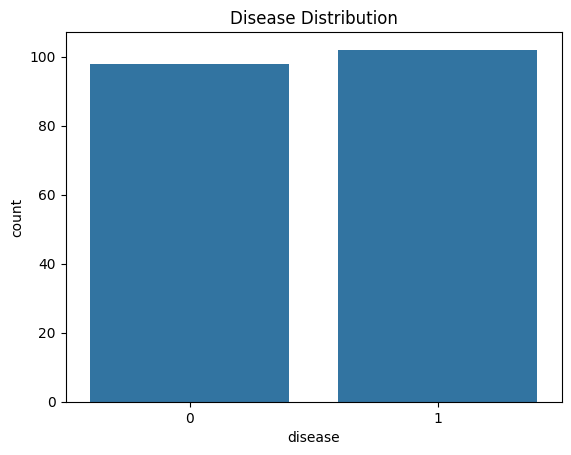

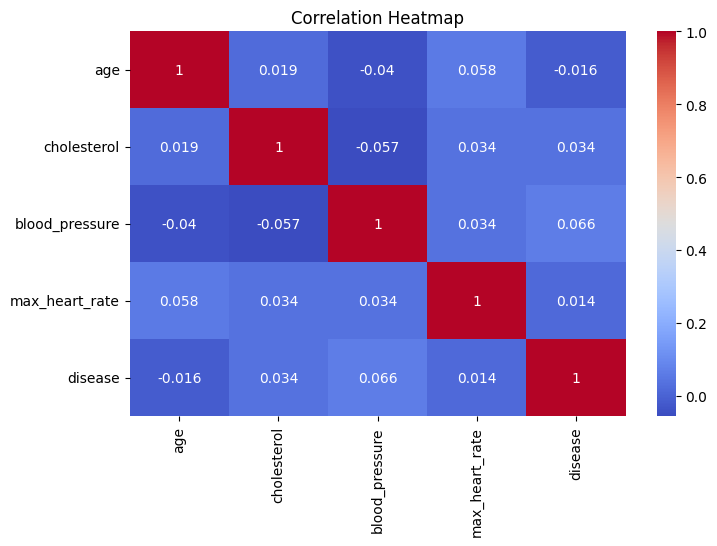

In [ ]:
# EDA
# Check missing values
print(df.isnull().sum())

# Distribution of target
sns.countplot(x="disease", data=df)
plt.title("Disease Distribution")
plt.show()

print()
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Features, Target, Split
X = df.drop("disease", axis=1)   # all columns except target
y = df["disease"]                  # target column

# Why axis=1? — drop column (axis=1) not row (axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keep same class distribution in split
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (140, 4)
Test size  : (60, 4)


In [ ]:
# Feature Scaling
scaler = StandardScaler()

# Fit ONLY on training data — never on test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Why fit only on train?
# If you fit on test data — test data influences scaling
# Model gets information about test set — data leakage

# Train Model

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)


LogisticRegression(random_state=42)

In [ ]:
# Predict
# Predict classes
predictions = model.predict(X_test_scaled)

# Predict probabilities — more useful
probabilities = model.predict_proba(X_test_scaled)

print("First 5 predictions:", predictions[:5])
print("\nFirst 5 probabilities:")
print(probabilities[:5])
# Each row — [probability of class 0, probability of class 1]

First 5 predictions: [1 1 1 0 0]

First 5 probabilities:
[[0.49204144 0.50795856]
 [0.37473843 0.62526157]
 [0.37902212 0.62097788]
 [0.66443541 0.33556459]
 [0.52117286 0.47882714]]


In [ ]:
# Evaluate — All Metrics
accuracy  = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall    = recall_score(y_test, predictions)
f1        = f1_score(y_test, predictions)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.4500
Precision : 0.4643
Recall    : 0.4194
F1 Score  : 0.4407


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
cm
# plt.figure(figsize=(6, 4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=["No Disease", "Disease"],
#             yticklabels=["No Disease", "Disease"])
# plt.title("Confusion Matrix")
# plt.ylabel("Actual")
# plt.xlabel("Predicted")
# plt.show()


array([[14, 15],
       [18, 13]])

In [ ]:
# Full report
print(classification_report(y_test, predictions,
      target_names=["No Disease", "Disease"]))

              precision    recall  f1-score   support

  No Disease       0.44      0.48      0.46        29
     Disease       0.46      0.42      0.44        31

    accuracy                           0.45        60
   macro avg       0.45      0.45      0.45        60
weighted avg       0.45      0.45      0.45        60



Support — how many actual samples of that class in test set.\
Macro avg — average across classes equally.\
Weighted avg — average weighted by support.

In [ ]:
# Predict New Patient
# New patient — age 55, cholesterol 250, bp 140, heart rate 150
new_patient = pd.DataFrame([[55, 250, 140, 150]],
              columns=["age", "cholesterol",
                       "blood_pressure", "max_heart_rate"])

# Scale new patient using same scaler
new_patient_scaled = scaler.transform(new_patient)

# Predict
pred  = model.predict(new_patient_scaled)
proba = model.predict_proba(new_patient_scaled)

print(f"Prediction  : {'Disease' if pred[0]==1 else 'No Disease'}")
print(f"Probability : {proba[0][1]:.4f}")

Prediction  : Disease
Probability : 0.5920
